In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.tokenize import RegexpTokenizer, word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
import re
from wordcloud import WordCloud
from Sastrawi.Stemmer import StemmerFactory


In [2]:
df = pd.read_csv('../labeling/data_labeled.csv')

In [3]:
#Proses Tokenisasi
tokenizer = RegexpTokenizer(r'\w+')
df['stemming'] = df['stemming'].apply(lambda x: tokenizer.tokenize(x))

df

,stemming,inset,senti
0,"[chale, man, start, dey, crypto, football, ay,...",neg,neg
1,"[bitcoin, orange, ogsatoshis]",neg,neg
2,"[wahyus, problem, besar, selesai, web, risiko,...",neg,pos
3,"[boomer, bilang, underwear, eh, underlyingnya,...",neg,neg
4,"[ek, aisi, wife, main, bhi, deserve, karta, hu...",neg,neg
...,...,...,...
1231,"[raja, mata, uang, crypto, bitcoin, postingan,...",neg,neg
1232,"[ktk, kampuni, zenye, market, cap, kubwa, duni...",pos,neg
1233,"[meinmokhtar, hang, keje, penuh, asb, dah, n, ...",neg,pos
1234,"[join, gabung, ajar, santuy, bareng, cryptoriz...",neg,pos


In [4]:
print(df['inset'].value_counts())
print(df['senti'].value_counts())


inset
neg    836
pos    400
Name: count, dtype: int64
senti
neg    963
pos    273
Name: count, dtype: int64


In [5]:
x = df['stemming']
y = df['senti']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)
print(f'Jumlah data latih x: {len(x_train)}\n', f'Jumlah data latih y: {len(y_train)}')
print(f'Jumlah data uji x: {len(x_test)}\n', f'Jumlah data uji y: {len(y_test)}')


Jumlah data latih x: 988
 Jumlah data latih y: 988
Jumlah data uji x: 248
 Jumlah data uji y: 248


In [6]:
y_test.value_counts()

senti
neg    190
pos     58
Name: count, dtype: int64

In [7]:
tfidf_vectorizer = TfidfVectorizer(analyzer=lambda x: x)

x_train_tfidf = tfidf_vectorizer.fit_transform(x_train)
x_test_tfidf = tfidf_vectorizer.transform(x_test)

print(x_train_tfidf, "\n")
print(x_test_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 11483 stored elements and shape (988, 4722)>
  Coords	Values
  (0, 3849)	0.17517163811581168
  (0, 1640)	0.18138872531769398
  (0, 1140)	0.16579705738620382
  (0, 2890)	0.1894039447596956
  (0, 2374)	0.33159411477240763
  (0, 4642)	0.36277745063538797
  (0, 3901)	0.18138872531769398
  (0, 863)	0.20070076207564627
  (0, 1970)	0.20070076207564627
  (0, 272)	0.17517163811581168
  (0, 3051)	0.20070076207564627
  (0, 3711)	0.35034327623162337
  (0, 931)	0.1351882033123009
  (0, 496)	0.03721343248908119
  (0, 1342)	0.1620766885597417
  (0, 3502)	0.1558596013578594
  (0, 534)	0.20070076207564627
  (0, 657)	0.35034327623162337
  (0, 1641)	0.16579705738620382
  (0, 3830)	0.17517163811581168
  (0, 4546)	0.18138872531769398
  (1, 2183)	0.6674007372847831
  (1, 3760)	0.6674007372847831
  (1, 2926)	0.3303823720228662
  (2, 2321)	0.16915267047735985
  :	:
  (984, 4246)	0.1921706681593664
  (984, 198)	0.2754542416454851
  (984, 2508)	0.306

# __PEMODELAN SVM__

In [8]:
model = SVC(kernel=['linear', 'rbf', 'poly'])

params_grid = [{'C': [0.01, 0.1, 0.5, 1, 10, 100, 1000], 'kernel': ['linear']},
               {'C': [0.01, 0.1, 0.5, 1, 10, 100, 1000], 'kernel': ['rbf'], 'gamma': [0.0001, 0.001, 0.01, 0.1]},
              {'C': [0.01, 0.1, 0.5, 1, 10, 100, 1000], 'kernel': ['poly'], 'gamma': [0.0001, 0.001, 0.01, 0.1], 'degree': [2, 3, 4]}
              ]

params_grid

[{'C': [0.01, 0.1, 0.5, 1, 10, 100, 1000], 'kernel': ['linear']},
 {'C': [0.01, 0.1, 0.5, 1, 10, 100, 1000],
  'kernel': ['rbf'],
  'gamma': [0.0001, 0.001, 0.01, 0.1]},
 {'C': [0.01, 0.1, 0.5, 1, 10, 100, 1000],
  'kernel': ['poly'],
  'gamma': [0.0001, 0.001, 0.01, 0.1],
  'degree': [2, 3, 4]}]

## __Pemodelan SVM dengan Fungsi Kernel Linear__

In [9]:
grid_linear = GridSearchCV(estimator=model,
                           param_grid=params_grid[0],
                           scoring='accuracy')

#pelatihan model kernel linear
grid_linear.fit(x_train_tfidf, y_train)

print("Best parameters found: ", grid_linear.best_estimator_)
print(f"Best Score: {grid_linear.best_score_ * 100:.2f} %")

Best parameters found:  SVC(C=10, kernel='linear')
Best Score: 85.43 %


## __Pemodelan SVM dengan Fungsi Kernel RBF__

In [10]:
grid_rbf = GridSearchCV(estimator=model,
                        param_grid=params_grid[1],
                        scoring='accuracy')
#pelatihan model kernel rbf
grid_rbf.fit(x_train_tfidf, y_train)

print("Best parameters found: ", grid_rbf.best_estimator_)
print(f"Best Score: {grid_rbf.best_score_ * 100:.2f} %")

Best parameters found:  SVC(C=100, gamma=0.1)
Best Score: 85.73 %


## __Pemodelan SVM dengan Fungsi Kernel Poly__

In [11]:
grid_poly = GridSearchCV(estimator=model,
                         param_grid=params_grid[2],
                         scoring='accuracy')

##pelatihan model kernel polynomial
grid_poly.fit(x_train_tfidf, y_train)

print("Best parameters found: ", grid_poly.best_estimator_)
print(f"Best Score: {grid_poly.best_score_ * 100:.2f} %")

Best parameters found:  SVC(C=1000, degree=2, gamma=0.1, kernel='poly')
Best Score: 80.87 %


# __EVALUASI__

### __Counfussion Matrix Kernel Linear__

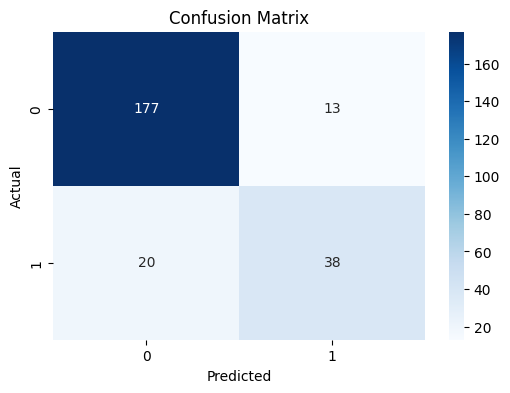

Classification Report:
              precision    recall  f1-score   support

         neg       0.90      0.93      0.91       190
         pos       0.75      0.66      0.70        58

    accuracy                           0.87       248
   macro avg       0.82      0.79      0.81       248
weighted avg       0.86      0.87      0.86       248

Nilai prediksi akurasi kernel linear:  86.69354838709677


In [12]:
# prediksi akurasi kernel linear 
y_pred_linear = grid_linear.best_estimator_.predict(x_test_tfidf)
akurasi_linear = accuracy_score(y_test, y_pred_linear)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_linear)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_linear))
print("Nilai prediksi akurasi kernel linear: ", akurasi_linear * 100)

### __Confussion Matrix Kernel RBF__

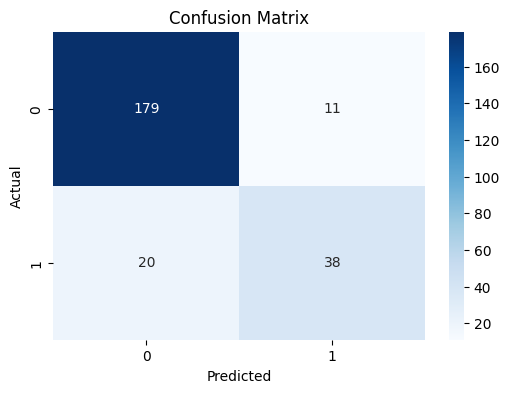

Confusion Matrix:
TP : 38
TN : 179
FP : 11
FN : 20


Classification Report:
              precision    recall  f1-score   support

         neg       0.90      0.94      0.92       190
         pos       0.78      0.66      0.71        58

    accuracy                           0.88       248
   macro avg       0.84      0.80      0.82       248
weighted avg       0.87      0.88      0.87       248

Nilai prediksi akurasi kernel rbf:  87.5


In [13]:
y_pred_rbf = grid_rbf.best_estimator_.predict(x_test_tfidf)
akurasi_rbf = accuracy_score(y_test, y_pred_rbf)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rbf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Confusion Matrix:")
print("TP :", cm[1][1])
print("TN :", cm[0][0])
print("FP :", cm[0][1])
print("FN :", cm[1][0])
print('\n')

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_rbf))
print("Nilai prediksi akurasi kernel rbf: ", akurasi_rbf * 100)

### __Confussion Matrix Kernel Polinomial__

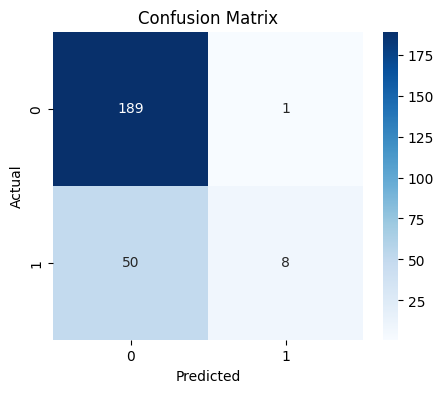

Confusion Matrix:
TP : 8
TN : 189
FP : 1
FN : 50


Classification Report:
              precision    recall  f1-score   support

         neg       0.79      0.99      0.88       190
         pos       0.89      0.14      0.24        58

    accuracy                           0.79       248
   macro avg       0.84      0.57      0.56       248
weighted avg       0.81      0.79      0.73       248

Nilai prediksi akurasi kernel poly:  79.43548387096774


In [14]:
y_pred_poly = grid_poly.best_estimator_.predict(x_test_tfidf)
akurasi_poly = accuracy_score(y_test, y_pred_poly)
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_poly)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Confusion Matrix:")
print("TP :", cm[1][1])
print("TN :", cm[0][0])
print("FP :", cm[0][1])
print("FN :", cm[1][0])
print('\n')

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_poly))
print("Nilai prediksi akurasi kernel poly: ", akurasi_poly * 100)

Dari ketiga confusion matrix kernel berbeda, hasil matrix tersebut menunjukkan bahwa TP = 154, TN = 33, FP = 31, FN = 18